# Download the example data from [here](https://drive.google.com/file/d/18hNnAjK5DTeyy7v-hv-nsLPlnIui_Utx) and unzip it
# Then you can run the notebook assuming the file paths are the same

In [1]:
import datetime as dtime
import gzip
import pathlib

import matplotlib.pyplot as plt
import umndet.helpers as hp

# Uncomment for high DPI display
%config InlineBackend.figure_format = 'retina'

plt.style.use("style")

## Loading in the data

In [2]:
science = []

data_folder = pathlib.Path("impress")
# Select data only from one hour
files = sorted(data_folder.glob("*_2026-270-03-*"))
for fn in files:
    if fn.stem.startswith("detsci-hist"):
        science += hp.read_impress_sci(fn, open_func=gzip.open)

# Look at a spectrogram over time of counts

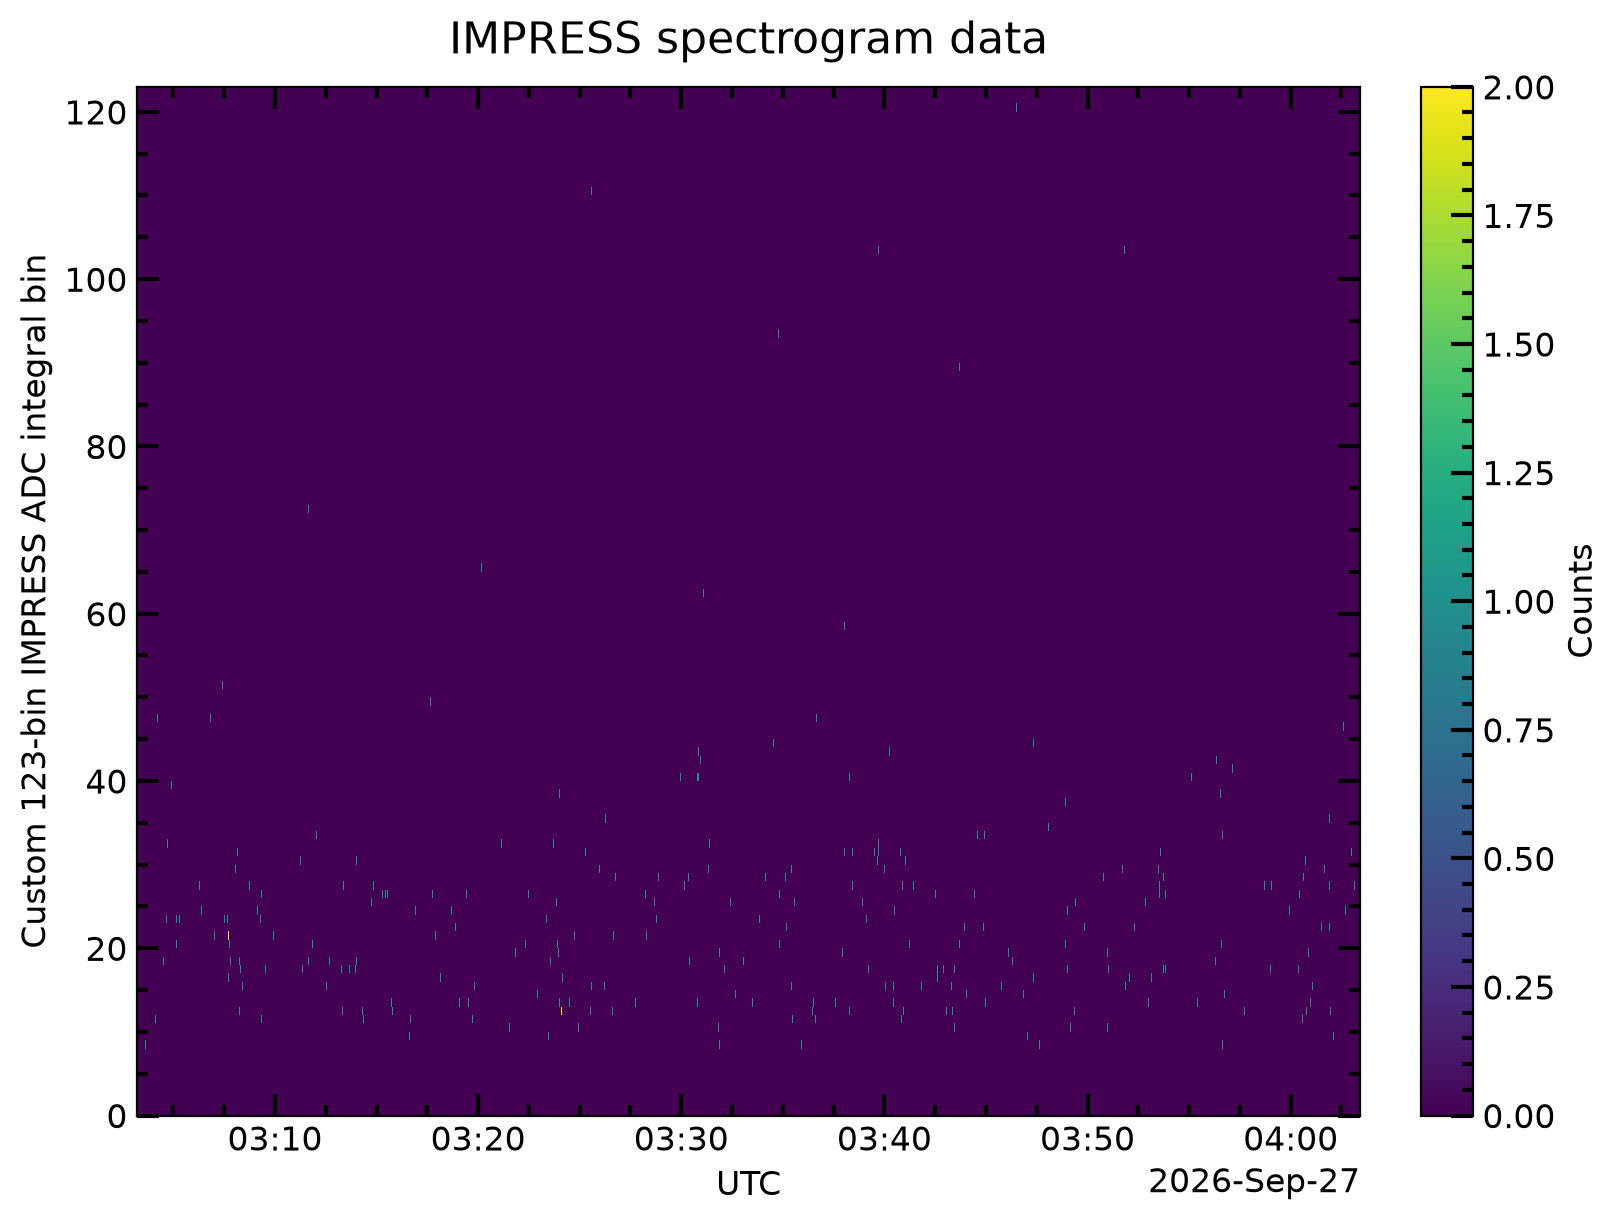

In [3]:
import numpy as np

# Build up a spectrogram array and a time array
# Assumes the science array is already sorted by time properly.
spectrogram = np.empty((123, len(science)), dtype=np.uint16)
time_bin_edges = []
dt = dtime.timedelta(microseconds=31250)
for i, s in enumerate(science):
    spectrogram[:, i] = s.histogram
    this_dt = (s.buffer_number % 32) * dt
    second = dtime.datetime.fromtimestamp(s.unix_second, tz=dtime.UTC)
    time_bin_edges.append(second + this_dt)

# We need one more time bin edge
time_bin_edges.append(time_bin_edges[-1] + dt)

fig, ax = plt.subplots(layout="constrained")

# We have 123 log-spaced science bins
adc_bin_edges = np.arange(124, dtype=np.uint8)
pcm = ax.pcolormesh(time_bin_edges, adc_bin_edges, spectrogram)
fig.colorbar(pcm, label="Counts")
ax.set(
    xlabel="UTC",
    ylabel="Custom 123-bin IMPRESS ADC integral bin",
    title="IMPRESS spectrogram data",
)
plt.show()